In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (10, 6)

sns.set_theme(style="whitegrid")

In [181]:
PALETTE = [
    "#AACC96",  # Tea Green
    "#25533F",  # Forest
    "#F4BEAE",  # Peach Frost
    "#52A5CE",  # Blue Berry
    "#FF7BAC",  # Bubblegum
    "#876029",  # Dry Earth
    "#6D1F42",  # Grape Juice
    "#D3B6D3",  # Lilacs
    "#EFCE7B",  # Butter Yellow
    "#B8CEE8",  # Iced Blue
    "#EF6F3C",  # Blood Orange
    "#AFAB23",  # Olive Green
]

sns.set_palette(PALETTE)

In [182]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nadyinky/sephora-products-and-skincare-reviews")

# print("Path to dataset files:", path)

In [183]:
from pathlib import Path

dataset_path = Path(path)

for file in dataset_path.iterdir():
    print(file.name)

product_info.csv
reviews_0-250.csv
reviews_1250-end.csv
reviews_750-1250.csv
reviews_250-500.csv
reviews_500-750.csv


In [184]:
products_df = pd.read_csv(dataset_path / "product_info.csv", low_memory=False)
reviews_df = pd.read_csv(dataset_path / "reviews_0-250.csv", low_memory=False)

In [185]:
print(reviews_df.columns)
print(products_df.columns)

Index(['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness',
       'total_feedback_count', 'total_neg_feedback_count',
       'total_pos_feedback_count', 'submission_time', 'review_text',
       'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color',
       'product_id', 'product_name', 'brand_name', 'price_usd'],
      dtype='object')
Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'variation_type', 'variation_value',
       'variation_desc', 'ingredients', 'price_usd', 'value_price_usd',
       'sale_price_usd', 'limited_edition', 'new', 'online_only',
       'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category',
       'secondary_category', 'tertiary_category', 'child_count',
       'child_max_price', 'child_min_price'],
      dtype='object')


In [186]:
reviews_df.head()

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,"I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil based and removes all of your makeup super easily. I follow-up with this water based cleanser, and I also use this just by itself when I’m not wearing make-up. It leaves the skin gently cleansed, but without stripping the skin. 10/10 recommend combining with the make-up melt. It’s perfection!",Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,"I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.",Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and apply lip balm daily but nothing helped until I started using this. untiluntistafted usinf this.,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the texture. Gummy Bear is my second most favourite scent. Grapefruit is the best in my opinion.,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must have. After a few weeks of use I have learned I will always have by my bedside. I thought it was a little expensive but a little goes a long way. It is worth the price.",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0


In [187]:
print("REVIEWS:" )
print(reviews_df.dtypes)

REVIEWS:
Unnamed: 0                    int64
author_id                    object
rating                        int64
is_recommended              float64
helpfulness                 float64
total_feedback_count          int64
total_neg_feedback_count      int64
total_pos_feedback_count      int64
submission_time              object
review_text                  object
review_title                 object
skin_tone                    object
eye_color                    object
skin_type                    object
hair_color                   object
product_id                   object
product_name                 object
brand_name                   object
price_usd                   float64
dtype: object


In [188]:
# Drop columns
reviews_df = reviews_df.drop(columns=["Unnamed: 0"], errors="ignore")

# Integer columns
reviews_df["author_id"] = reviews_df["author_id"].astype("string")

# Boolean columns
reviews_df["is_recommended"] = reviews_df["is_recommended"].astype("boolean")

# Date column
reviews_df["submission_time"] = pd.to_datetime(
    reviews_df["submission_time"],
    errors="coerce"
)

# Categorical columns
categorical_columns = [
    "skin_tone",
    "eye_color",
    "skin_type",
    "hair_color",
    "product_id",
    "product_name",
    "brand_name"
]

reviews_df[categorical_columns] = reviews_df[categorical_columns].astype("category")

reviews_df.dtypes


author_id                   string[python]
rating                               int64
is_recommended                     boolean
helpfulness                        float64
total_feedback_count                 int64
total_neg_feedback_count             int64
total_pos_feedback_count             int64
submission_time             datetime64[ns]
review_text                         object
review_title                        object
skin_tone                         category
eye_color                         category
skin_type                         category
hair_color                        category
product_id                        category
product_name                      category
brand_name                        category
price_usd                          float64
dtype: object

In [189]:
reviews_df.isnull().sum()


author_id                        0
rating                           0
is_recommended              117486
helpfulness                 331832
total_feedback_count             0
total_neg_feedback_count         0
total_pos_feedback_count         0
submission_time                  0
review_text                    999
review_title                167011
skin_tone                   106056
eye_color                   138488
skin_type                    74683
hair_color                  141081
product_id                       0
product_name                     0
brand_name                       0
price_usd                        0
dtype: int64

In [190]:
reviews_df = reviews_df.dropna(subset=["review_text"])

reviews_df['review_title'] = reviews_df['review_title'].fillna("No title")
for col in ['skin_tone', 'eye_color', 'skin_type', 'hair_color']:
    if col in reviews_df.columns:
        if pd.api.types.is_categorical_dtype(reviews_df[col]):
            if "Doesn't apply" not in reviews_df[col].cat.categories:
                reviews_df[col] = reviews_df[col].cat.add_categories("Doesn't apply")
        reviews_df[col] = reviews_df[col].fillna("Doesn't apply")
        
# reviews_df['helpfulness'] = reviews_df['helpfulness'].fillna(0).round(2)
dropcolumns = ['is_recommended',
               'total_feedback_count',
               'total_neg_feedback_count',
               'total_pos_feedback_count']

reviews_df = reviews_df.drop(columns=dropcolumns, errors="ignore")

reviews_df.isnull().sum()

/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/2130234963.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(reviews_df[col]):


author_id               0
rating                  0
helpfulness        331072
submission_time         0
review_text             0
review_title            0
skin_tone               0
eye_color               0
skin_type               0
hair_color              0
product_id              0
product_name            0
brand_name              0
price_usd               0
dtype: int64

In [191]:
products_df.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,variation_desc,ingredients,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,NaN,"['Capri Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) D-Limonene, Linalool, Benzyl Salicylate, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Benzl Benzoate, Citral, Geraniol, Eugenol, Benzyl Alcohol, Farnesol, Citronellol, Isoeugenol.', 'Invisible Post Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Ethylhexyl Methoxycinnamate, Ethylhexyl Salicylate, Butyl Methoxydibenzoylmethane, Benzyl Benzoate, Citral, Coumarin, Limonene, Alpha-Isomethyl Ionone, Linalool.', 'Kashbah Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Coumarin, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, D-Limonene, Eugenol, Linalool, Citronellol, Geraniol, Cinnamal, Citral.', 'L’Air Barbes Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Benzyl Salicylate, D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Linalool Citral, Alphaisomethyl Ionone, Benzyl Benzoate, Geraniol Farnesol, Isoeugenol, Eugenol.', 'La Habana Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Ethylhexyl Methoxycinnamate, Ethylhexyl Salicylate, Butyl Methoxydibenzoylmethane, Benzyl Alcohol, Benzyl Benzoate, Benzyl Cinnamate, Cinnamal, Citral, Coumarin Limonene, Eugenol, Alpha-Isomethyl Ionone, Linalool.', 'Purple Haze Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Octoxynol-10, D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Geraniol, Linalool, Coumarin, Farnesol, Eugenol, Citral.', 'Rainbow Bar Eau de Parfum:', 'Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Hexyl Cinnamal, Citronellol, Linalool, Coumarin, Eugenol, Citral, Isoeugenol, Geraniol.']",35.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scent', 'Woody & Earthy Scent', 'Fresh Scent']",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Ethylhexyl Methoxycinnamate, Ethylhexyl Salicylate, Butyl Methoxydibenzoylmethane, Benzyl Alcohol, Benzyl Benzoate, Benzyl Cinnamate, Cinnamal, Citral, Coumarin Limonene, Eugenol, Alpha-Isomethyl Ionone, Linalool.']",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent', 'Warm &Spicy Scent']",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) D-Limonene, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, Hexyl Cinnamal Citronellol, Linalool, Coumarin, Eugenol, Citral, Isoeugenol, Geraniol.']",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent', 'Woody & Earthy Scent']",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,NaN,"['Alcohol Denat. (SD Alcohol 39C), Parfum (Fragrance) Coumarin, Ethylhexyl Methoxycinnamate, Butyl Methoxydibenzoylmethane, Ethylhexyl Salicylate, D-Limonene, Eugenol, Linalool, Citronellol, Geraniol, Cinnamal, Citral.']",195.0,NaN,NaN,0,0,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent', 'Warm &Spicy Scent']",Fragranc

In [192]:
print("PRODUCTS:")
products_df.dtypes

PRODUCTS:


product_id             object
product_name           object
brand_id                int64
brand_name             object
loves_count             int64
rating                float64
reviews               float64
size                   object
variation_type         object
variation_value        object
variation_desc         object
ingredients            object
price_usd             float64
value_price_usd       float64
sale_price_usd        float64
limited_edition         int64
new                     int64
online_only             int64
out_of_stock            int64
sephora_exclusive       int64
highlights             object
primary_category       object
secondary_category     object
tertiary_category      object
child_count             int64
child_max_price       float64
child_min_price       float64
dtype: object

In [193]:
# String
products_df["product_id"] = products_df["product_id"].astype("string")

# Categorical columns
categorical_columns = [
    "product_name",
    "brand_name",
    "size",
    "variation_type",
    "variation_value",
    "variation_desc",
    "primary_category",
    "secondary_category",
    "tertiary_category"
]

existing_categorical_columns = [col for col in categorical_columns if col in products_df.columns]
products_df[existing_categorical_columns] = products_df[existing_categorical_columns].astype("category")

# Boolean columns
boolean_columns = [
    "limited_edition",
    "new",
    "online_only",
    "out_of_stock",
    "sephora_exclusive"
]

products_df[boolean_columns] = products_df[boolean_columns].astype("boolean")

# Text columns
products_df["ingredients"] = products_df["ingredients"].astype("string")
products_df["highlights"] = products_df["highlights"].astype("string")

products_df.dtypes

product_id            string[python]
product_name                category
brand_id                       int64
brand_name                  category
loves_count                    int64
rating                       float64
reviews                      float64
size                        category
variation_type              category
variation_value             category
variation_desc              category
ingredients           string[python]
price_usd                    float64
value_price_usd              float64
sale_price_usd               float64
limited_edition              boolean
new                          boolean
online_only                  boolean
out_of_stock                 boolean
sephora_exclusive            boolean
highlights            string[python]
primary_category            category
secondary_category          category
tertiary_category           category
child_count                    int64
child_max_price              float64
child_min_price              float64
d

In [194]:
products_df.isnull().sum()

product_id               0
product_name             0
brand_id                 0
brand_name               0
loves_count              0
rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1598
variation_desc        7244
ingredients            945
price_usd                0
value_price_usd       8043
sale_price_usd        8224
limited_edition          0
new                      0
online_only              0
out_of_stock             0
sephora_exclusive        0
highlights            2207
primary_category         0
secondary_category       8
tertiary_category      990
child_count              0
child_max_price       5740
child_min_price       5740
dtype: int64

In [195]:
products_df = products_df.dropna(subset=["reviews"])
products_df = products_df.dropna(subset=["tertiary_category"])

dropcolumns = [
    "variation_type",
    "variation_value",
    "variation_desc",
    "value_price_usd",
    "sale_price_usd",
    "child_max_price",
    "child_min_price"]

products_df = products_df.drop(columns=dropcolumns, errors="ignore")

products_df['highlights'] = products_df['highlights'].fillna("No highlights")
products_df['ingredients'] = products_df['ingredients'].fillna("No information")


if "size" in products_df.columns:
    if "No information" not in products_df["size"].cat.categories:
        products_df["size"] = products_df["size"].cat.add_categories("No information")

    products_df["size"] = products_df["size"].fillna("No information")

products_df['rating'] = products_df['rating'].fillna(0).round(2)


products_df.isnull().sum()

product_id            0
product_name          0
brand_id              0
brand_name            0
loves_count           0
rating                0
reviews               0
size                  0
ingredients           0
price_usd             0
limited_edition       0
new                   0
online_only           0
out_of_stock          0
sephora_exclusive     0
highlights            0
primary_category      0
secondary_category    0
tertiary_category     0
child_count           0
dtype: int64

In [197]:
# products_df.head()
reviews_df.head()

,author_id,rating,helpfulness,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,1741593524,5,1.0,2023-02-01,"I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil based and removes all of your makeup super easily. I follow-up with this water based cleanser, and I also use this just by itself when I’m not wearing make-up. It leaves the skin gently cleansed, but without stripping the skin. 10/10 recommend combining with the make-up melt. It’s perfection!",Taught me how to double cleanse!,Doesn't apply,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,31423088263,1,NaN,2023-03-21,"I bought this lip mask after reading the reviews and the hype. Unfortunately, it did not meet my expectations as vaseline petroleum jelly works way better for me.",Disappointed,Doesn't apply,Doesn't apply,Doesn't apply,Doesn't apply,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0
2,5061282401,5,NaN,2023-03-21,My review title says it all! I get so excited to get into bed and apply this lip mask. I do see a difference because I suffer from dry cracked lips. I drink a lot of water and apply lip balm daily but nothing helped until I started using this. untiluntistafted usinf this.,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0
3,6083038851,5,NaN,2023-03-20,I’ve always loved this formula for a long time. I honestly don’t even use it for night time. I use it as an everyday lip balm. I love the texture. Gummy Bear is my second most favourite scent. Grapefruit is the best in my opinion.,Can't go wrong with any of them,Doesn't apply,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0
4,47056667835,5,NaN,2023-03-20,"If you have dry cracked lips, this is a must have. After a few weeks of use I have learned I will always have by my bedside. I thought it was a little expensive but a little goes a long way. It is worth the price.",A must have !!!,light,hazel,combination,Doesn't apply,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.0


# Rating Distribution
### Questions to answer:
- Are most reviews positive?
- Is the dataset balanced?
- Do customers tend to leave extreme ratings?


/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/345679717.py:1: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.countplot(data=reviews_df, x="rating", hue="rating", legend=False, palette=PALETTE)
/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/345679717.py:4: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  ax = sns.countplot(


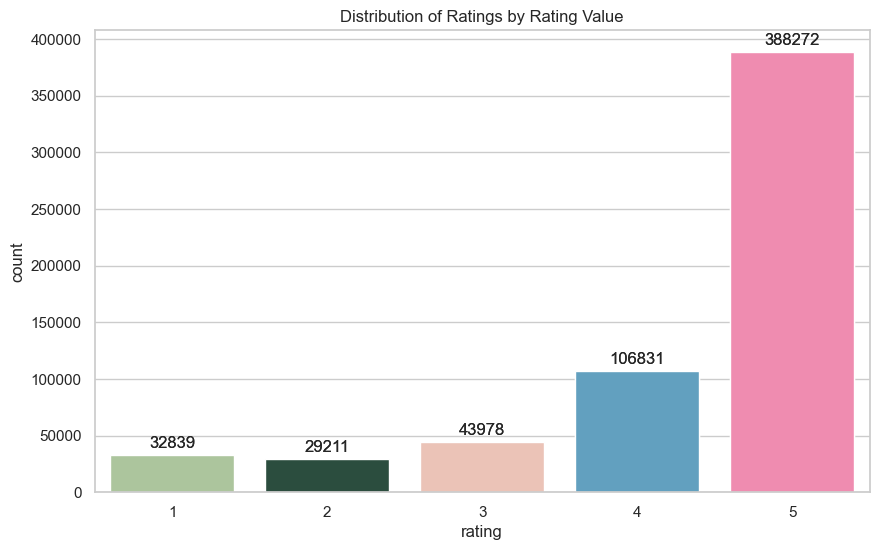

In [200]:
sns.countplot(data=reviews_df, x="rating", hue="rating", legend=False, palette=PALETTE)
plt.title("Distribution of Ratings by Rating Value")

ax = sns.countplot(
    data=reviews_df,
    x="rating",
    hue="rating",
    legend=False,
    palette=PALETTE,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
    
plt.show()

/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/1598944126.py:6: UserWarning: The palette list has more values (12) than needed (2), which may not be intended.
  ax = sns.countplot(data=reviews_df, x="rating_group", hue="rating_group", palette=PALETTE, dodge=False)


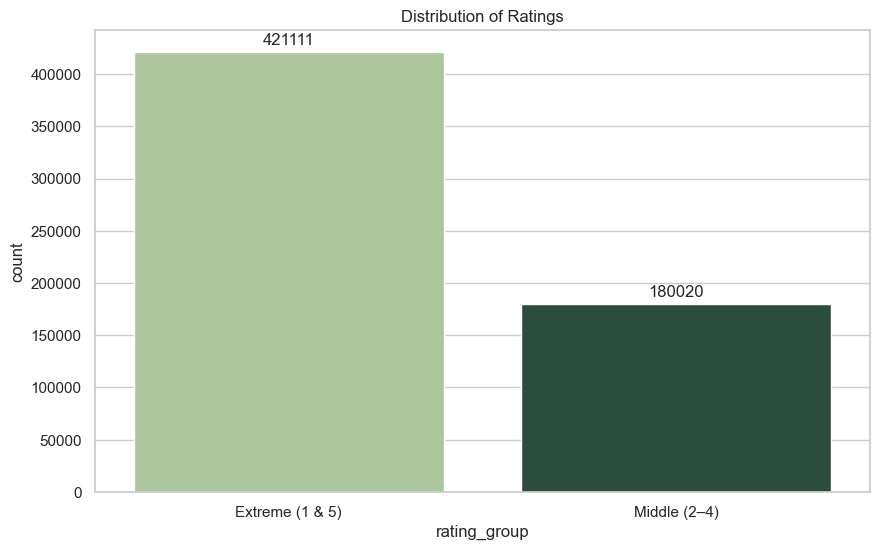

In [202]:
reviews_df["rating_group"] = pd.Categorical(
    reviews_df["rating"].apply(lambda x: "Extreme (1 & 5)" if x in [1, 5] else "Middle (2–4)"),
    categories=["Extreme (1 & 5)", "Middle (2–4)"],
)

ax = sns.countplot(data=reviews_df, x="rating_group", hue="rating_group", palette=PALETTE, dodge=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Distribution of Ratings")
plt.show()

### Observation

- The distribution of ratings is highly imbalanced, with **5-star reviews dominating the dataset (388,272 reviews)**. Ratings of **4 stars** are the second most common, while ratings of **1–3 stars** occur much less frequently.
- Grouping ratings into **Extreme (1 & 5)** and **Middle (2–4)** categories shows that extreme ratings are more common overall. However, this pattern is almost entirely driven by the exceptionally large number of **5-star reviews** rather than by a high frequency of **1-star reviews**.
- Although **1-star ratings** are more frequent than **2-star ratings**, they remain relatively rare compared with **5-star ratings**.

Overall, customers exhibit a strong positive rating bias, with the vast majority of reviews awarding the maximum score. This creates a highly skewed rating distribution that should be considered in any subsequent analysis or predictive modelling.

# Price Distribution
### Questions
- What is the typical product price?
- Are there luxury outliers?
- Is the distribution skewed?


/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/999525927.py:1: UserWarning: The palette list has more values (12) than needed (9), which may not be intended.
  ax = sns.countplot(data=products_df, x="primary_category", hue="primary_category", palette=PALETTE, dodge=False)


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Bath & Body'),
  Text(1, 0, 'Fragrance'),
  Text(2, 0, 'Gifts'),
  Text(3, 0, 'Hair'),
  Text(4, 0, 'Makeup'),
  Text(5, 0, 'Men'),
  Text(6, 0, 'Mini Size'),
  Text(7, 0, 'Skincare'),
  Text(8, 0, 'Tools & Brushes')])

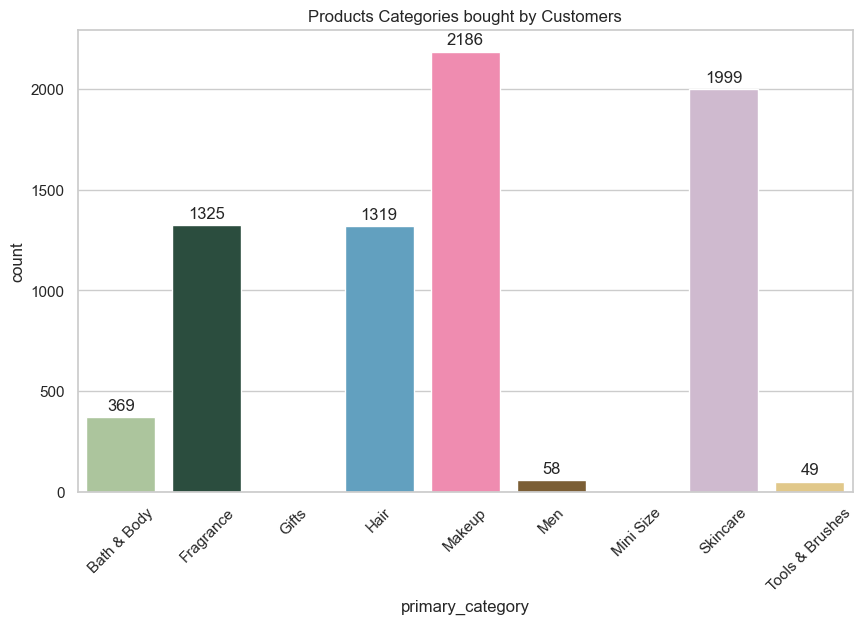

In [203]:
ax = sns.countplot(data=products_df, x="primary_category", hue="primary_category", palette=PALETTE, dodge=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Products Categories bought by Customers")
plt.xticks(rotation=45)

/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/812616483.py:1: UserWarning: The palette list has more values (12) than needed (9), which may not be intended.
  sns.histplot(data=products_df, x="price_usd", hue="primary_category", palette=PALETTE, bins=30, kde=True)


Text(0, 0.5, 'Frequency')

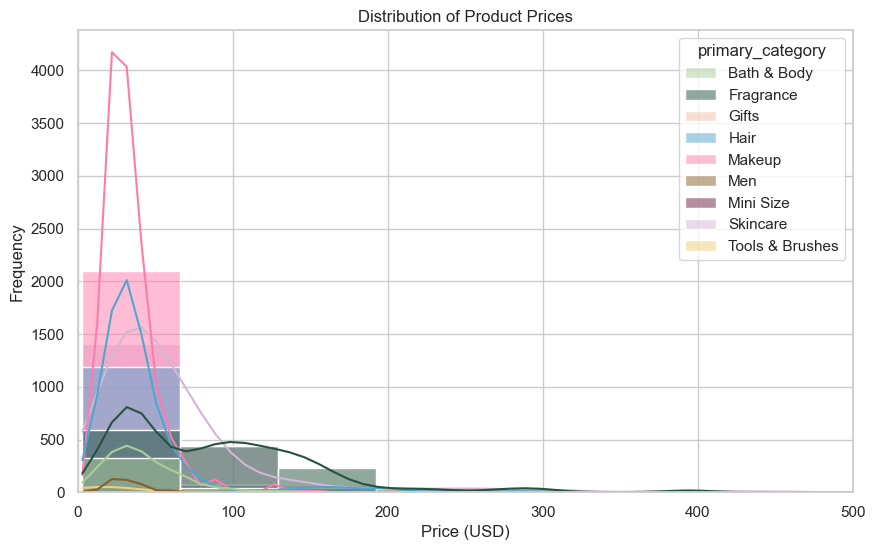

In [204]:
sns.histplot(data=products_df, x="price_usd", hue="primary_category", palette=PALETTE, bins=30, kde=True)
plt.xlim(0, 500)
plt.title("Distribution of Product Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")

The distribution of product prices differs across the primary product categories. Most products are priced below **$100**, resulting in right-skewed distributions where higher-priced items are relatively rare.

Among all categories, **Fragrance** exhibits the widest price range and contains the most expensive products. In contrast, **Makeup**, **Hair**, and **Bath & Body** products are primarily concentrated at lower price points. **Skincare** also displays a relatively broad price distribution, indicating greater price variability than most other categories.

Although some categories tend to have distinct price ranges, there is considerable overlap between the distributions. This suggests that product price alone is not sufficient to clearly differentiate between the various product categories.

/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/1381464178.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=products_df, x="primary_category", y="price_usd", palette=PALETTE)
/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/1381464178.py:1: UserWarning: The palette list has more values (12) than needed (9), which may not be intended.
  sns.boxenplot(data=products_df, x="primary_category", y="price_usd", palette=PALETTE)


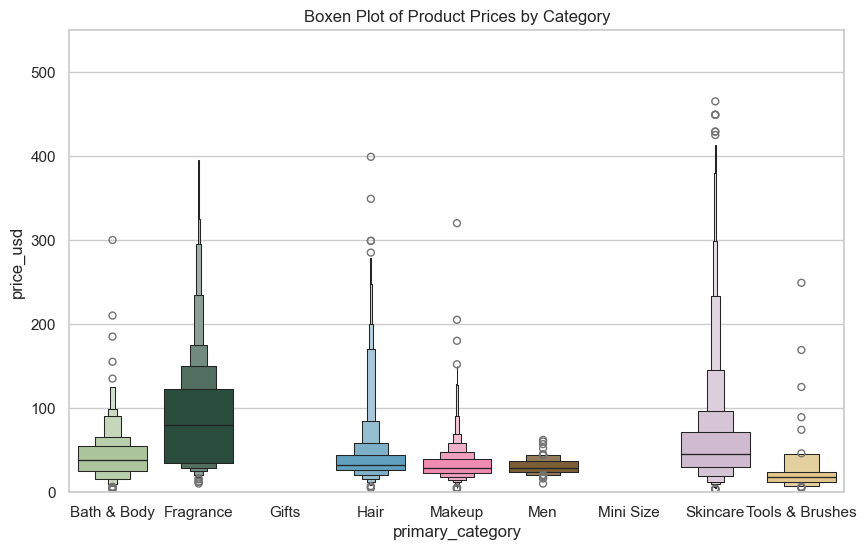

In [205]:
sns.boxenplot(data=products_df, x="primary_category", y="price_usd", palette=PALETTE)
plt.ylim(0, 550)
plt.title("Boxen Plot of Product Prices by Category")
plt.show()

The boxplot highlights substantial differences in product price distributions across the primary categories. **Fragrance** products have the highest median price and the greatest variability, with a wide interquartile range and numerous high-priced outliers. **Skincare** also exhibits a broad price distribution and contains several premium products, including some of the highest-priced items in the dataset.

In contrast, **Makeup**, **Hair**, **Bath & Body**, and **Men** products generally have lower median prices and narrower interquartile ranges, indicating that prices within these categories are more consistent. **Tools & Brushes** are typically among the least expensive products, although a small number of high-priced outliers are present.

Most categories contain outliers, suggesting that premium or luxury products exist across nearly all product types. Overall, the boxplot confirms that **Fragrance** and **Skincare** display the greatest price variability, whereas the remaining categories tend to have lower and more concentrated price distributions.

### Observation

- Product prices are concentrated in the lower price ranges, with the majority of products costing **less than \$100**. The distributions are strongly **right-skewed**, indicating that premium-priced products are relatively uncommon across all categories.
- **Fragrance** products have the **highest median price** and the **greatest price variability**, exhibiting the widest interquartile range and numerous high-priced outliers. This category also contains some of the most expensive products in the dataset.
- **Skincare** displays the second-highest level of price variation, with a broad distribution and several premium products priced well above the category median.
- In contrast, **Makeup**, **Hair**, **Bath & Body**, **Men**, and **Tools & Brushes** have noticeably lower median prices and more compact distributions, suggesting that products within these categories are generally more affordable and consistently priced.
- Outliers are present in nearly every category, indicating that premium or luxury products exist across the entire product portfolio, although they represent only a small proportion of all products.

Overall, the analysis reveals that while most Sephora products are positioned within an affordable price range, pricing differs substantially between categories. **Fragrance** and **Skincare** represent the premium segments of the catalogue, whereas the remaining categories are characterized by lower and more concentrated price distributions.

# Brand Popularity
### Questions
- Which brands have the most products?
- Which brands receive the highest ratings?
- Which brands receive the most reviews?


/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/3420746244.py:4: UserWarning: 
The palette list has fewer values (12) than needed (60) and will cycle, which may produce an uninterpretable plot.
  ax = sns.countplot(


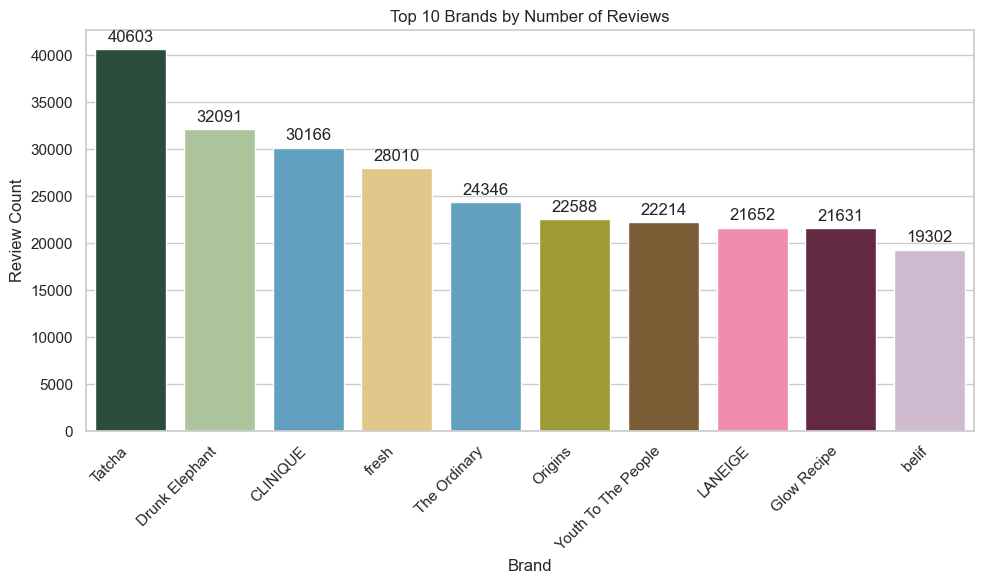

In [206]:
top_brands_by_reviews = reviews_df["brand_name"].value_counts().nlargest(10).index


ax = sns.countplot(
    data=reviews_df,
    x="brand_name",
    hue="brand_name",
    order=top_brands_by_reviews,
    palette=PALETTE,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Top 10 Brands by Number of Reviews")
plt.xlabel("Brand")
plt.ylabel("Review Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/1937270493.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/1937270493.py:7: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  ax = sns.barplot(


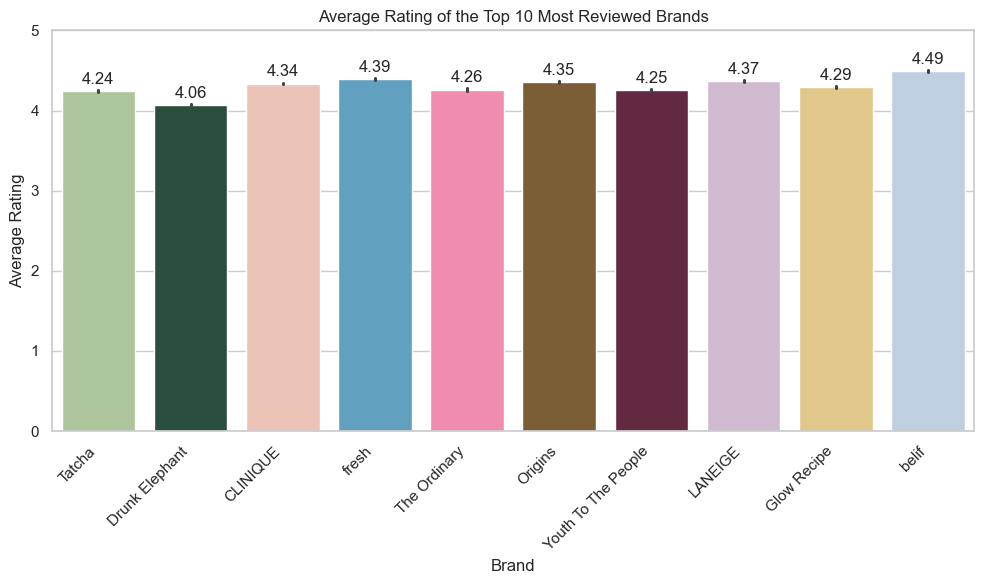

In [207]:
top_brands_by_reviews = reviews_df["brand_name"].value_counts().nlargest(10).index

top_brands_df = reviews_df[
    reviews_df["brand_name"].isin(top_brands_by_reviews)
]

ax = sns.barplot(
    data=top_brands_df,
    x="brand_name",
    y="rating",
    palette=PALETTE,
    order=top_brands_by_reviews
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Average Rating of the Top 10 Most Reviewed Brands")
plt.xlabel("Brand")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Observation

- **Tatcha** received the largest number of reviews (**40,603**), making it the most frequently reviewed brand in the dataset. It is followed by **Drunk Elephant** (**32,091**) and **CLINIQUE** (**30,166**), indicating that these brands have the highest customer engagement.
- Despite differences in review volume, the **average ratings of the top 10 brands are consistently high**, ranging from **4.06** to **4.49**. This suggests that the most popular brands generally receive positive customer feedback.
- **belif** has the **highest average rating (4.49)** among the top 10 most-reviewed brands, although it has the lowest review count within this group (**19,302**). Conversely, **Drunk Elephant** has the lowest average rating (**4.06**) despite being the second most-reviewed brand.
- **Tatcha**, the most-reviewed brand, maintains a strong average rating of **4.24**, indicating that its popularity is accompanied by generally positive customer satisfaction.
- The relatively narrow spread of average ratings (less than **0.5 stars** between the highest- and lowest-rated brands) suggests that all of the top brands are well regarded by customers, with no brand receiving notably poor ratings.

Overall, the results indicate that the most frequently reviewed brands are consistently rated highly. While review volume varies considerably across brands, average customer satisfaction remains relatively stable, with all top brands achieving average ratings above **4.0**.

# Category Analysis
### Questions
- Which categories dominate Sephora?
- Which categories are highest rated?
- Which are most expensive?


/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/2764377474.py:3: UserWarning: The palette list has more values (12) than needed (9), which may not be intended.
  ax = sns.countplot(


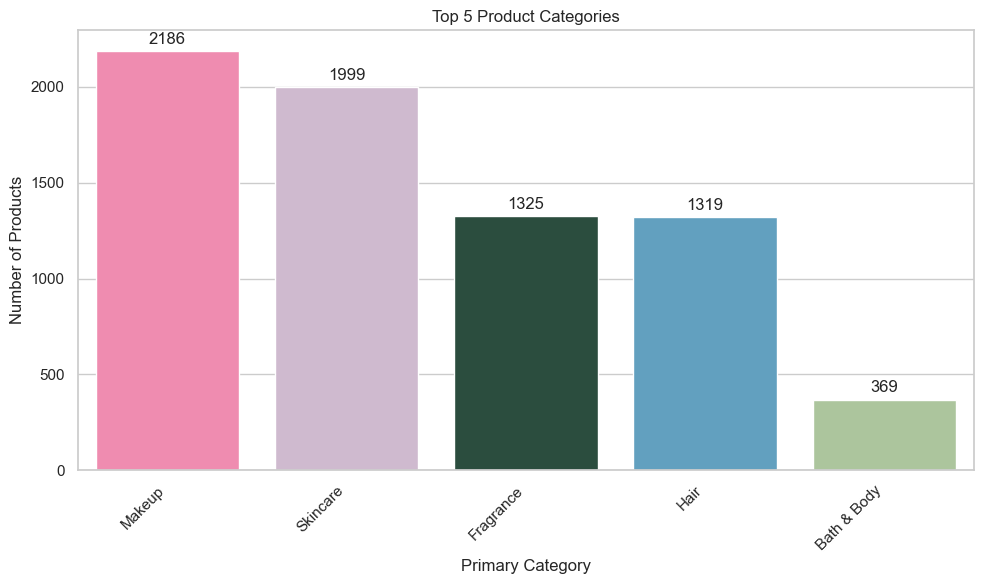

In [208]:
top_categories = products_df["primary_category"].value_counts().nlargest(5).index

ax = sns.countplot(
    data=products_df,
    x="primary_category",
    hue="primary_category",
    order=top_categories,
    palette=PALETTE,
    dodge=False,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Top 5 Product Categories")
plt.xlabel("Primary Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/2304662728.py:10: UserWarning: The palette list has more values (12) than needed (6), which may not be intended.
  ax = sns.countplot(


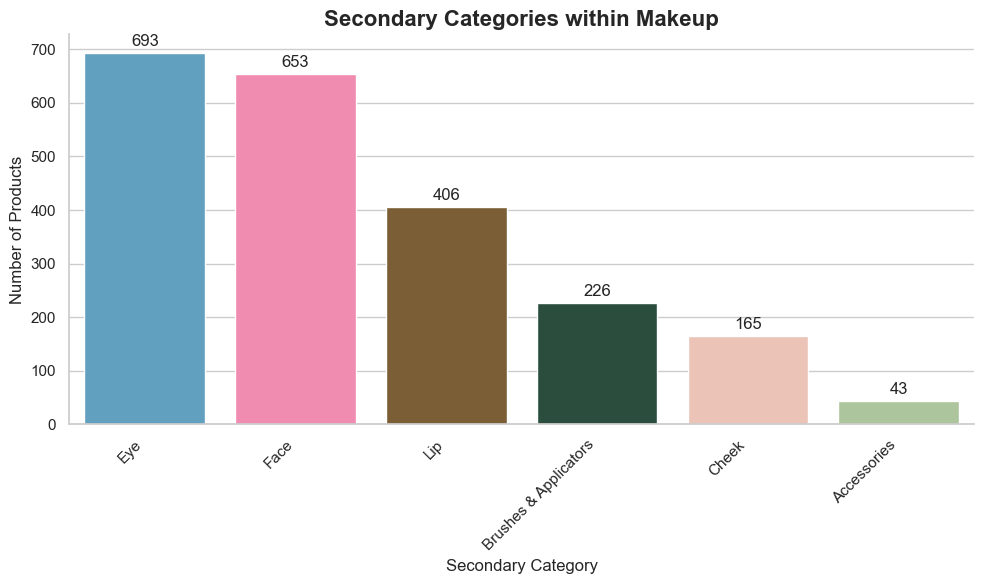

In [209]:
makeup_df = products_df[products_df["primary_category"] == "Makeup"].copy()

makeup_df["secondary_category"] = (
    makeup_df["secondary_category"]
    .cat.remove_unused_categories()
)

order = makeup_df["secondary_category"].value_counts().index

ax = sns.countplot(
    data=makeup_df,
    x="secondary_category",
    order=order,
    hue="secondary_category",
    palette=PALETTE,
    dodge=False,
    legend=False
)


for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)


plt.title("Secondary Categories within Makeup", fontsize=16, weight="bold")
plt.xlabel("Secondary Category", fontsize=12)
plt.ylabel("Number of Products", fontsize=12)
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()

plt.show()

/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/2058416722.py:10: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  ax = sns.countplot(


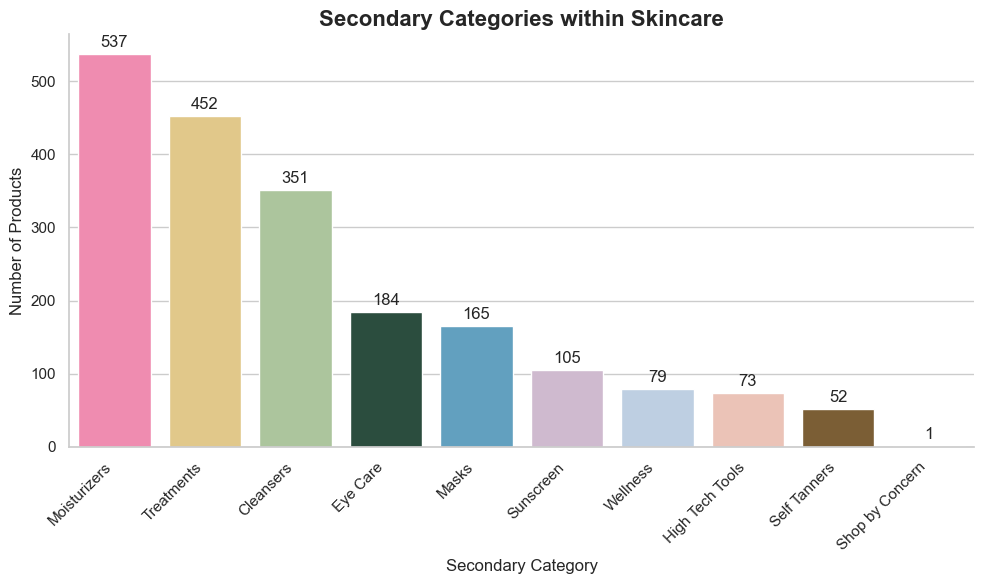

In [210]:
skincare_df = products_df[products_df["primary_category"] == "Skincare"].copy()

skincare_df["secondary_category"] = (
    skincare_df["secondary_category"]
    .cat.remove_unused_categories()
)

order = skincare_df["secondary_category"].value_counts().index

ax = sns.countplot(
    data=skincare_df,
    x="secondary_category",
    order=order,
    hue="secondary_category",
    palette=PALETTE,
    dodge=False,
    legend=False
)


for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)


plt.title("Secondary Categories within Skincare", fontsize=16, weight="bold")
plt.xlabel("Secondary Category", fontsize=12)
plt.ylabel("Number of Products", fontsize=12)
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()

plt.show()

/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_10952/341106262.py:10: UserWarning: The palette list has more values (12) than needed (4), which may not be intended.
  ax = sns.countplot(


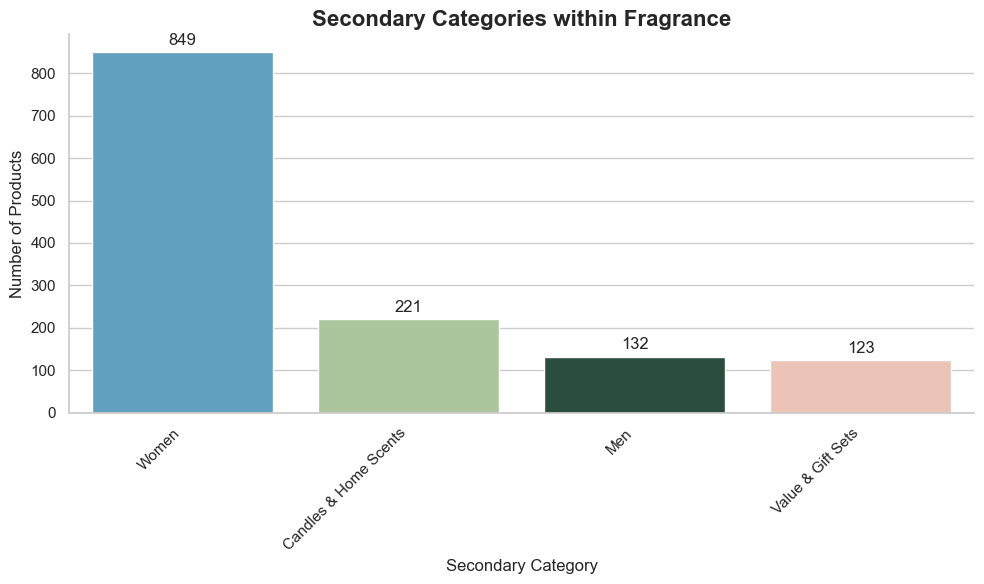

In [211]:
fragrance_df = products_df[products_df["primary_category"] == "Fragrance"].copy()

fragrance_df["secondary_category"] = (
    fragrance_df["secondary_category"]
    .cat.remove_unused_categories()
)

order = fragrance_df["secondary_category"].value_counts().index

ax = sns.countplot(
    data=fragrance_df,
    x="secondary_category",
    order=order,
    hue="secondary_category",
    palette=PALETTE,
    dodge=False,
    legend=False
)


for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)


plt.title("Secondary Categories within Fragrance", fontsize=16, weight="bold")
plt.xlabel("Secondary Category", fontsize=12)
plt.ylabel("Number of Products", fontsize=12)
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()

plt.show()

### Observations

The category analysis highlights that **Makeup** and **Skincare** dominate Sephora's product portfolio, accounting for the largest number of products in the dataset. This suggests that these two categories represent the company's primary focus and are likely to receive the greatest attention from customers.

Within the **Makeup** category, the product assortment is concentrated around **Eye** and **Face** products, followed by **Lip** products. These three subcategories together represent the majority of makeup offerings, while categories such as **Brushes & Applicators**, **Cheek**, and **Accessories** occupy a much smaller share of the catalog.

A similar pattern can be observed in **Skincare**, where **Moisturizers**, **Treatments**, and **Cleansers** account for most available products. Specialized categories such as **Eye Care**, **Masks**, **Sunscreen**, and **Wellness** are present but considerably less represented, indicating that Sephora's skincare assortment is primarily focused on daily skincare routines.

The **Fragrance** category is strongly dominated by **Women's fragrances**, which significantly outnumber products in **Men**, **Candles & Home Scents**, and **Value & Gift Sets**. This suggests that Sephora's fragrance portfolio is primarily targeted toward the women's market.

Overall, the product catalog is not evenly distributed across categories. Instead, Sephora appears to prioritize a few core beauty segments while maintaining smaller supporting categories that broaden the overall product selection. These findings provide useful context for the subsequent analyses, where customer ratings, prices, and product popularity will be examined across different product groups.

# Correlation Analysis

AttributeError: QuadMesh.set() got an unexpected keyword argument 'palette'

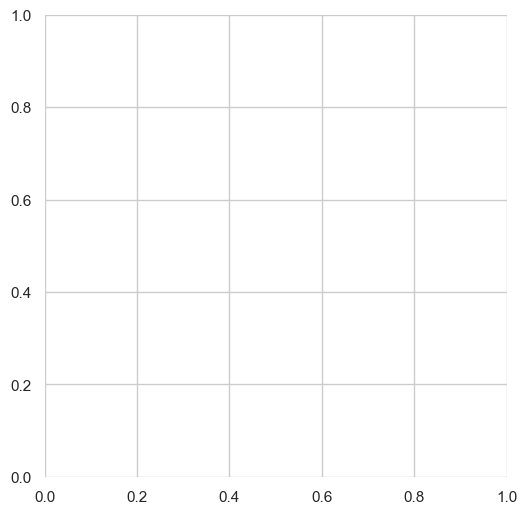

In [ ]:
# Select only numerical columns
numeric_columns = [
    "loves_count",
    "rating",
    "reviews",
    "price_usd",
    "sale_price_usd",
]

# Use only columns that exist (fallback to all numeric columns if none from the list are present)
numeric_columns_present = [c for c in numeric_columns if c in products_df.columns]
if not numeric_columns_present:
    numeric_columns_present = products_df.select_dtypes(include=["number"]).columns.tolist()

corr_matrix = products_df[numeric_columns_present].corr(numeric_only=True)


sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Product Features", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

### Observations

The correlation analysis indicates that most product characteristics exhibit weak linear relationships. The strongest positive correlation is observed between **loves_count** and **reviews** (0.71), suggesting that products receiving more customer attention also tend to accumulate more user reviews.

Interestingly, **product rating shows almost no correlation with either price, number of reviews, or loves count**. This suggests that customer satisfaction is largely independent of a product's popularity or price point. Likewise, product price demonstrates negligible correlation with the remaining variables, indicating that more expensive products are not necessarily more popular or better rated.

Overall, the analysis suggests that while customer engagement metrics are closely related to one another, **price and rating appear to be driven by different factors**, motivating further investigation in the subsequent machine learning analyses.